In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
target = "load_actual"

# Train–test split by timestamp
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

y_train = train[target]
y_test = test[target]

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns=["timestamp", target])
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

gbr.fit(X_train_scaled, y_train)
y_pred_gb = gbr.predict(X_test_scaled)

# Metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print("GB MAE :", mae_gb)
print("GB RMSE:", rmse_gb)
print("GB MAPE:", mape_gb)


GB MAE : 3000.139822243602
GB RMSE: 3749.785279240799
GB MAPE: 10.639066850976302


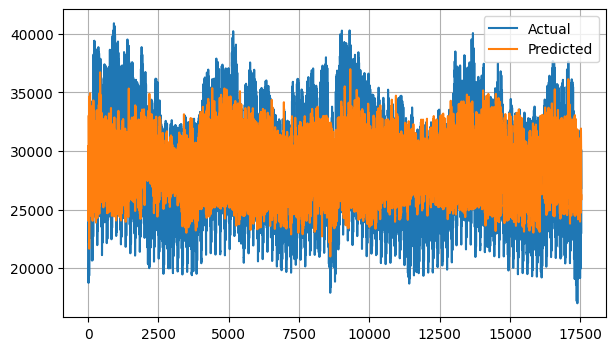

In [24]:
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_gb, label="Predicted")
plt.legend()
plt.grid(True)
plt.show()
